
## Environmental Monitoring: Beijing Multi-Site Air Quality Prediction using ANN

## Dataset Source: https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data

## Classification - Safe vs Hazardous Air Quality



## 1. IMPORT & SETUP ENVIRONMENT

In [ ]:
import sys
import os
import zipfile
import glob

if 'google.colab' in sys.modules:
    print("="*50)
    print("GOOGLE COLAB ENVIRONMENT DETECTED")
    print("="*50)

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # Check GPU
    !nvidia-smi

    print("\n✅ Environment ready")

# Regular imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Enable GPU memory growth
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print(f"✅ GPU: {physical_devices[0]}")
    except:
        pass

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print(f"\nTensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

GOOGLE COLAB ENVIRONMENT DETECTED
Mounted at /content/drive
Tue Jun  9 06:57:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |            

## 2. UPLOAD DATASET

In [ ]:
# Upload the archive.zip file
from google.colab import files

print("="*50)
print("STEP 1: Upload your archive.zip file")
print("="*50)
print("Please click 'Choose Files' and select your archive.zip")
print("This file should contain the PRSA_Data_20130301-20170228 folder")
print()

uploaded = files.upload()

# Find the uploaded zip file
zip_filename = None
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        zip_filename = filename
        break

if zip_filename is None:
    print("❌ No ZIP file found! Please upload archive.zip")
else:
    print(f"✅ Found ZIP file: {zip_filename}")

# Extract the zip file
print("\nExtracting ZIP file...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/')
    print(f"✅ Extracted to /content/")

# List extracted contents
print("\nExtracted files/folders:")
for item in os.listdir('/content/'):
    if 'PRSA' in item or 'archive' in item.lower():
        print(f"  - {item}")

# Find the folder containing CSV files
csv_folder = None
for folder in ['PRSA_Data_20130301-20170228', 'PRSA_Data_20130301-20170228/PRSA_Data_20130301-20170228']:
    if os.path.exists(f'/content/{folder}'):
        csv_folder = f'/content/{folder}'
        break

if csv_folder is None:
    # Search for any folder with CSVs
    for root, dirs, files in os.walk('/content/'):
        for file in files:
            if file.endswith('.csv') and 'PRSA' in file:
                csv_folder = root
                break
        if csv_folder:
            break

print(f"\n✅ CSV folder found: {csv_folder}")

# List all CSV files
csv_files = glob.glob(f'{csv_folder}/*.csv') if csv_folder else []
print(f"\nFound {len(csv_files)} CSV files:")
for f in csv_files[:5]:  # Show first 5
    print(f"  - {os.path.basename(f)}")
if len(csv_files) > 5:
    print(f"  ... and {len(csv_files)-5} more")

STEP 1: Upload your archive.zip file
Please click 'Choose Files' and select your archive.zip
This file should contain the PRSA_Data_20130301-20170228 folder



Saving archive.zip to archive.zip
✅ Found ZIP file: archive.zip

Extracting ZIP file...
✅ Extracted to /content/

Extracted files/folders:
  - archive.zip
  - PRSA_Data_20130301-20170228

✅ CSV folder found: /content/PRSA_Data_20130301-20170228

Found 12 CSV files:
  - PRSA_Data_Wanshouxigong_20130301-20170228.csv
  - PRSA_Data_Dongsi_20130301-20170228.csv
  - PRSA_Data_Gucheng_20130301-20170228.csv
  - PRSA_Data_Shunyi_20130301-20170228.csv
  - PRSA_Data_Wanliu_20130301-20170228.csv
  ... and 7 more


## 3. LOAD AND MERGE ALL DATASET FILE

In [ ]:
print("="*50)
print("STEP 2: Loading and Merging All CSV Files")
print("="*50)

# Dictionary to store each site's data
site_data = {}

for file_path in csv_files:
    # Extract site name from filename
    filename = os.path.basename(file_path)
    site_name = filename.replace('PRSA_Data_', '').replace('.csv', '').replace('_20130301-20170228', '')

    # Read CSV
    df_site = pd.read_csv(file_path)

    # Add site column if not present
    if 'station' not in df_site.columns:
        df_site['station'] = site_name

    site_data[site_name] = df_site
    print(f"✅ Loaded {site_name}: {len(df_site)} rows, {len(df_site.columns)} columns")

print(f"\nTotal sites loaded: {len(site_data)}")

# Merge all sites into one dataframe
print("\nMerging all sites...")
df = pd.concat(site_data.values(), ignore_index=True)
print(f"✅ Merged dataset shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

# Display first few rows
print("\nFirst 5 rows of merged dataset:")
df.head()

STEP 2: Loading and Merging All CSV Files
✅ Loaded Wanshouxigong: 35064 rows, 18 columns
✅ Loaded Dongsi: 35064 rows, 18 columns
✅ Loaded Gucheng: 35064 rows, 18 columns
✅ Loaded Shunyi: 35064 rows, 18 columns
✅ Loaded Wanliu: 35064 rows, 18 columns
✅ Loaded Changping: 35064 rows, 18 columns
✅ Loaded Tiantan: 35064 rows, 18 columns
✅ Loaded Nongzhanguan: 35064 rows, 18 columns
✅ Loaded Huairou: 35064 rows, 18 columns
✅ Loaded Aotizhongxin: 35064 rows, 18 columns
✅ Loaded Guanyuan: 35064 rows, 18 columns
✅ Loaded Dingling: 35064 rows, 18 columns

Total sites loaded: 12

Merging all sites...
✅ Merged dataset shape: (420768, 18)
   Rows: 420,768
   Columns: 18

First 5 rows of merged dataset:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


## 4. DATA OVERVIEW

In [ ]:
print("="*50)
print("STEP 3: Data Overview ")
print("="*50)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print("\n--- Statistical Summary ---")
df.describe()

# Check class distribution for PM2.5
PM25_THRESHOLD = 75  # Hazardous threshold
if 'PM2.5' in df.columns:
    print(f"\n--- PM2.5 Statistics ---")
    print(f"Mean: {df['PM2.5'].mean():.2f}")
    print(f"Median: {df['PM2.5'].median():.2f}")
    print(f"Min: {df['PM2.5'].min():.2f}")
    print(f"Max: {df['PM2.5'].max():.2f}")

STEP 3: Data Overview and Cleaning

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usag


## 5. DATA CLEANING

In [ ]:
print("="*50)
print("STEP 4: Data Cleaning")
print("="*50)

# Make a copy for cleaning
df_clean = df.copy()

# Drop rows with missing PM2.5 (target variable)
initial_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['PM2.5'])
print(f"Dropped {initial_rows - len(df_clean)} rows with missing PM2.5")

# Forward fill for meteorological features (small gaps)
meteo_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in meteo_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(method='ffill').fillna(method='bfill')

# Drop any remaining rows with missing values
df_clean = df_clean.dropna()
print(f"Final dataset shape: {df_clean.shape}")

# Remove duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")

# Create datetime column
if all(col in df_clean.columns for col in ['year', 'month', 'day', 'hour']):
    df_clean['datetime'] = pd.to_datetime(df_clean[['year', 'month', 'day', 'hour']])
    print("✅ Datetime column created")

# Create binary target
df_clean['target'] = (df_clean['PM2.5'] > PM25_THRESHOLD).astype(int)

print(f"\n--- Target Distribution ---")
print(df_clean['target'].value_counts())
print(f"\nPercentage:")
print(f"Safe (PM2.5 ≤ {PM25_THRESHOLD}): {(df_clean['target']==0).mean()*100:.1f}%")
print(f"Hazardous (PM2.5 > {PM25_THRESHOLD}): {(df_clean['target']==1).mean()*100:.1f}%")

STEP 4: Data Cleaning
Dropped 8739 rows with missing PM2.5
Final dataset shape: (382251, 18)
✅ Datetime column created

--- Target Distribution ---
target
0    233585
1    148666
Name: count, dtype: int64

Percentage:
Safe (PM2.5 ≤ 75): 61.1%
Hazardous (PM2.5 > 75): 38.9%


## 6. EXPLORATORY DATA ANALYSIS

STEP 5: Exploratory Data Analysis


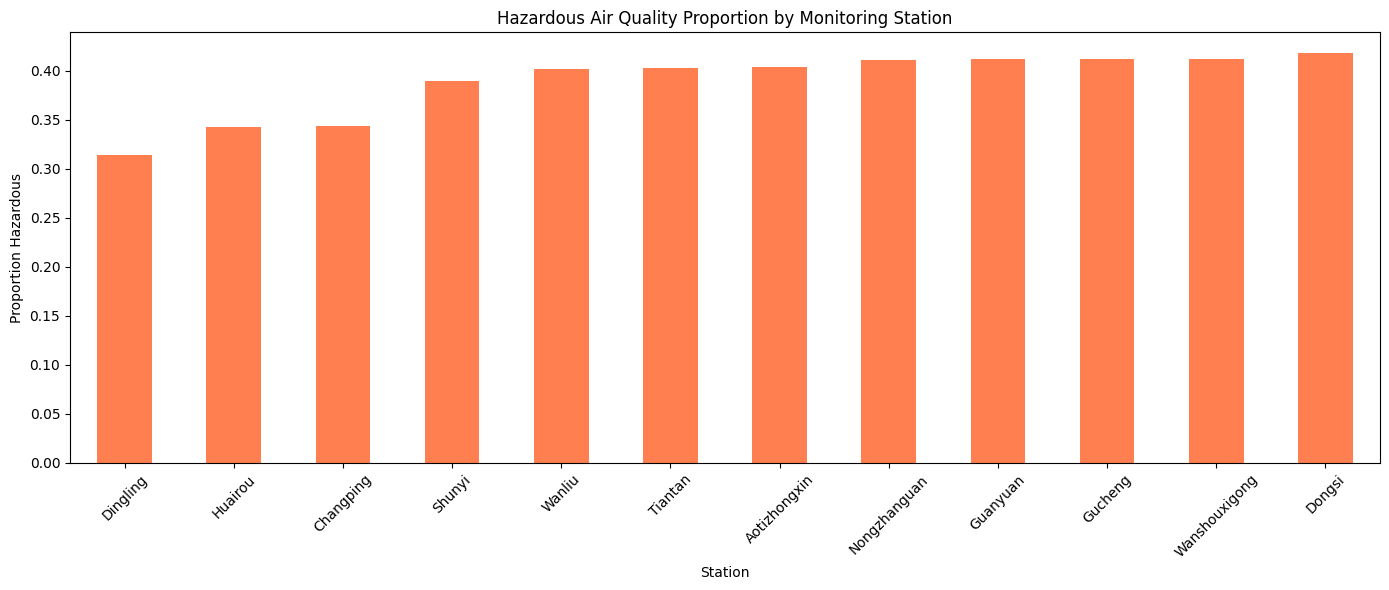


Hazardous proportion by station:
  Dingling: 31.4%
  Huairou: 34.2%
  Changping: 34.4%
  Shunyi: 39.0%
  Wanliu: 40.2%
  Tiantan: 40.3%
  Aotizhongxin: 40.4%
  Nongzhanguan: 41.1%
  Guanyuan: 41.2%
  Gucheng: 41.3%
  Wanshouxigong: 41.3%
  Dongsi: 41.8%


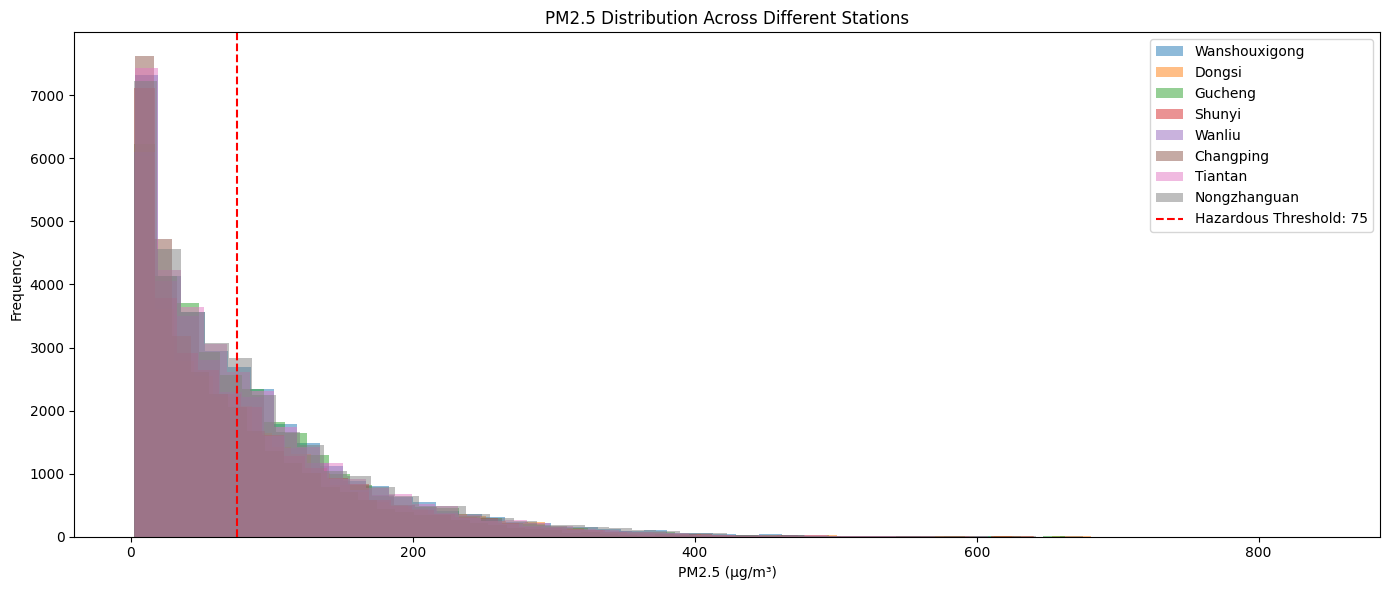

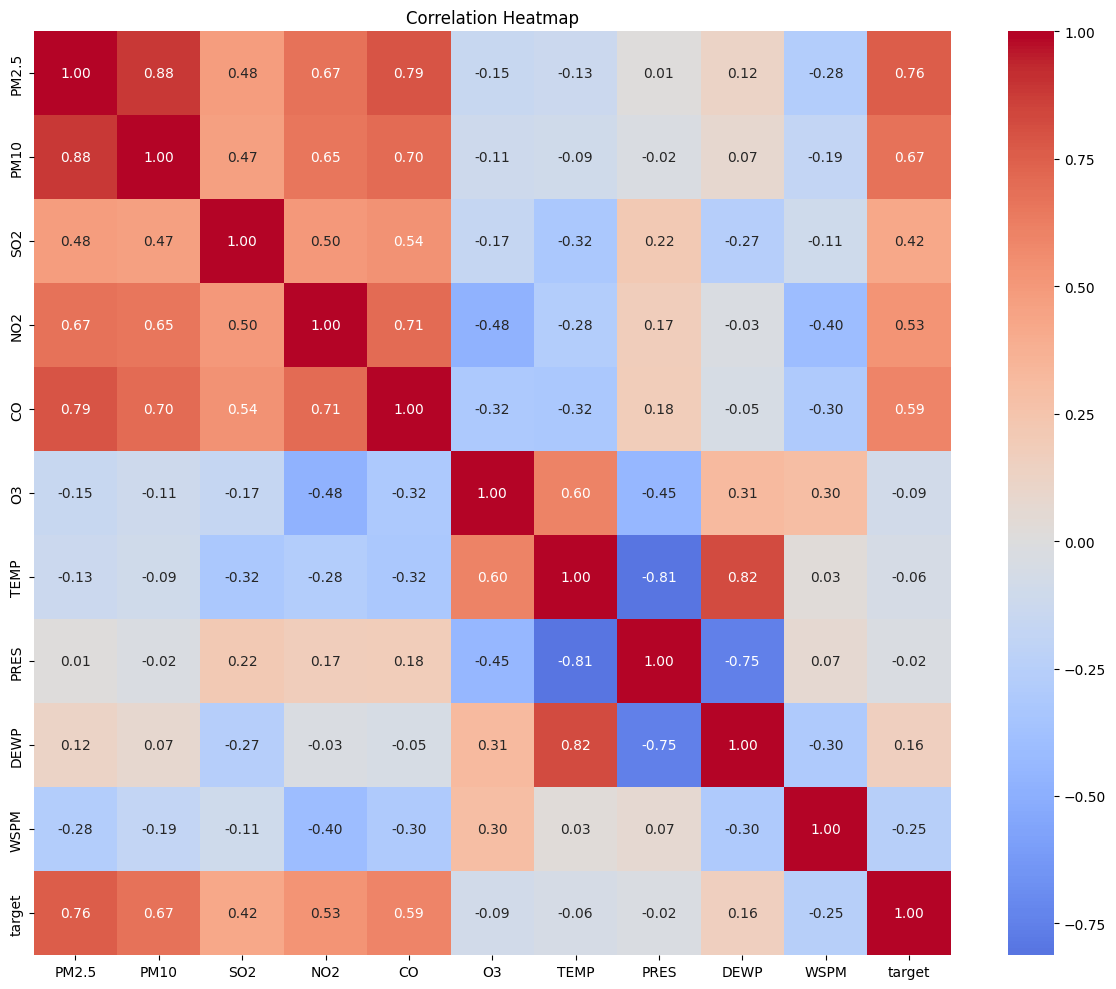


Correlation with target (Hazardous class):
target    1.000000
PM2.5     0.756400
PM10      0.672492
CO        0.591134
NO2       0.529140
SO2       0.421498
DEWP      0.158903
PRES     -0.023981
TEMP     -0.059366
O3       -0.087214
WSPM     -0.249469
Name: target, dtype: float64


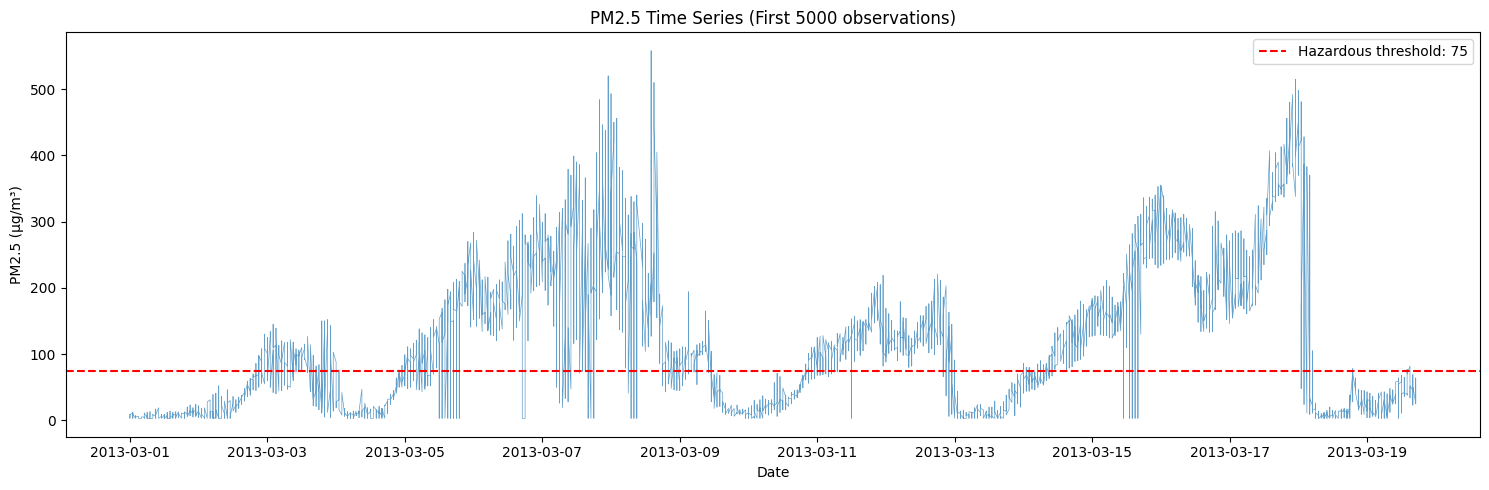

In [ ]:
print("="*50)
print("STEP 5: Exploratory Data Analysis")
print("="*50)

# 1. Class distribution by station
if 'station' in df_clean.columns:
    plt.figure(figsize=(14, 6))
    station_hazard = df_clean.groupby('station')['target'].mean().sort_values()
    station_hazard.plot(kind='bar', color='coral')
    plt.title('Hazardous Air Quality Proportion by Monitoring Station')
    plt.xlabel('Station')
    plt.ylabel('Proportion Hazardous')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\nHazardous proportion by station:")
    for station, prop in station_hazard.items():
        print(f"  {station}: {prop*100:.1f}%")

# 2. PM2.5 distribution by station
plt.figure(figsize=(14, 6))
stations = df_clean['station'].unique()[:8]  # Show first 8 for clarity
for station in stations:
    subset = df_clean[df_clean['station'] == station]['PM2.5']
    plt.hist(subset, bins=50, alpha=0.5, label=station)
plt.axvline(x=PM25_THRESHOLD, color='red', linestyle='--', label=f'Hazardous Threshold: {PM25_THRESHOLD}')
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('Frequency')
plt.title('PM2.5 Distribution Across Different Stations')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']
available_cols = [col for col in numeric_cols if col in df_clean.columns] + ['target']
corr_matrix = df_clean[available_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nCorrelation with target (Hazardous class):")
print(corr_matrix['target'].sort_values(ascending=False))

# 4. Time series of PM2.5 (first 5000 rows for readability)
if 'datetime' in df_clean.columns:
    df_sorted = df_clean.sort_values('datetime')
    plt.figure(figsize=(15, 5))
    plt.plot(df_sorted['datetime'][:5000], df_sorted['PM2.5'][:5000], alpha=0.7, linewidth=0.5)
    plt.axhline(y=PM25_THRESHOLD, color='red', linestyle='--', label=f'Hazardous threshold: {PM25_THRESHOLD}')
    plt.xlabel('Date')
    plt.ylabel('PM2.5 (μg/m³)')
    plt.title('PM2.5 Time Series (First 5000 observations)')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. FEATURE SELECTION AND DATA SPLIT

In [ ]:
print("="*50)
print("STEP 6: Feature Selection and Data Split")
print("="*50)

# Select features for modeling
feature_candidates = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
available_features = [col for col in feature_candidates if col in df_clean.columns]

# Remove PM2.5 from features (it's our target)
if 'PM2.5' in available_features:
    available_features.remove('PM2.5')

print(f"Selected features: {available_features}")

# Prepare X and y
X = df_clean[available_features].copy()
y = df_clean['target'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# Split data (temporal split - respect time order)
if 'datetime' in df_clean.columns:
    df_sorted = df_clean.sort_values('datetime')
    X_sorted = df_sorted[available_features]
    y_sorted = df_sorted['target']

    n = len(X_sorted)
    train_end = int(n * 0.7)
    val_end = int(n * 0.85)

    X_train = X_sorted[:train_end]
    X_val = X_sorted[train_end:val_end]
    X_test = X_sorted[val_end:]

    y_train = y_sorted[:train_end]
    y_val = y_sorted[train_end:val_end]
    y_test = y_sorted[val_end:]

    print("\nUsing temporal split (respecting time order)")
else:
    # Random split fallback
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    print("\nUsing random stratified split")

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Feature scaling completed")

STEP 6: Feature Selection and Data Split
Selected features: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
X shape: (382251, 10)
y shape: (382251,)
Class weights: {0: np.float64(0.8182267696983967), 1: np.float64(1.2856032986695007)}

Using temporal split (respecting time order)
Train shape: (267575, 10)
Validation shape: (57338, 10)
Test shape: (57338, 10)

✅ Feature scaling completed


## 8. BASELINE MODEL (LOGISTIC REGRESSION)

In [ ]:
print("="*50)
print("STEP 7: Baseline Model (Logistic Regression)")
print("="*50)

baseline = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Safe', 'Hazardous']))

STEP 7: Baseline Model (Logistic Regression)
Accuracy: 0.9240
Precision: 0.9198
Recall: 0.8859
F1-Score: 0.9025

Classification Report:
              precision    recall  f1-score   support

        Safe       0.93      0.95      0.94     34562
   Hazardous       0.92      0.89      0.90     22776

    accuracy                           0.92     57338
   macro avg       0.92      0.92      0.92     57338
weighted avg       0.92      0.92      0.92     57338



## 9. ANN MODEL WITH HYPERPARAMETER TUNING

In [ ]:
print("="*50)
print("STEP 8: ANN Model with Hyperparameter Tuning")
print("="*50)

def create_ann_model(input_dim, hidden_layers=[128, 64, 32], dropout_rates=[0.3, 0.2, 0.2], learning_rate=0.001):
    """Create ANN model with L2 regularization"""
    model = Sequential()

    # Input + first hidden layer
    model.add(Dense(hidden_layers[0], activation='relu', input_dim=input_dim,
                    kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(dropout_rates[0]))

    # Additional hidden layers
    for i in range(1, len(hidden_layers)):
        model.add(Dense(hidden_layers[i], activation='relu',
                        kernel_regularizer=regularizers.l2(0.001)))
        if i < len(dropout_rates):
            model.add(Dropout(dropout_rates[i]))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

    return model

# Hyperparameter configurations
input_dim = X_train_scaled.shape[1]

configurations = [
    {'name': 'Config 1 (Default)', 'hidden_layers': [128, 64, 32], 'dropout_rates': [0.3, 0.2, 0.2], 'lr': 0.001},
    {'name': 'Config 2 (Smaller)', 'hidden_layers': [64, 32], 'dropout_rates': [0.3, 0.2], 'lr': 0.001},
    {'name': 'Config 3 (Deeper)', 'hidden_layers': [256, 128, 64, 32], 'dropout_rates': [0.4, 0.3, 0.2, 0.2], 'lr': 0.0005},
    {'name': 'Config 4 (Wider)', 'hidden_layers': [256, 128], 'dropout_rates': [0.4, 0.3], 'lr': 0.001},
]

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train configurations
results = []
best_val_accuracy = 0
best_model = None
best_config_name = None

for config in configurations:
    print(f"\n{'='*40}")
    print(f"Training {config['name']}")
    print(f"{'='*40}")

    model = create_ann_model(
        input_dim=input_dim,
        hidden_layers=config['hidden_layers'],
        dropout_rates=config['dropout_rates'],
        learning_rate=config['lr']
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping, reduce_lr],
        class_weight=class_weight_dict,
        verbose=0
    )

    val_loss, val_acc, val_prec, val_rec = model.evaluate(X_val_scaled, y_val, verbose=0)

    results.append({
        'config': config['name'],
        'val_accuracy': val_acc,
        'val_precision': val_prec,
        'val_recall': val_rec,
        'epochs_trained': len(history.history['loss']),
        'model': model,
        'history': history
    })

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Validation Precision: {val_prec:.4f}")
    print(f"Validation Recall: {val_rec:.4f}")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model = model
        best_config_name = config['name']

print(f"\n✅ Best model: {best_config_name} (Val Acc: {best_val_accuracy:.4f})")

STEP 8: ANN Model with Hyperparameter Tuning

Training Config 1 (Default)
Validation Accuracy: 0.9271
Validation Precision: 0.8731
Validation Recall: 0.8888

Training Config 2 (Smaller)
Validation Accuracy: 0.9211
Validation Precision: 0.8755
Validation Recall: 0.8623

Training Config 3 (Deeper)
Validation Accuracy: 0.9215
Validation Precision: 0.8854
Validation Recall: 0.8512

Training Config 4 (Wider)
Validation Accuracy: 0.9182
Validation Precision: 0.8772
Validation Recall: 0.8492

✅ Best model: Config 1 (Default) (Val Acc: 0.9271)


## 10. MODEL EVALUATION

STEP 9: Final Model Evaluation on Test Set
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

Model: Config 1 (Default)

Test Set Performance:
Accuracy:  0.9356
Precision: 0.8984
Recall:    0.9449
F1-Score:  0.9210

Classification Report:
              precision    recall  f1-score   support

        Safe       0.96      0.93      0.95     34562
   Hazardous       0.90      0.94      0.92     22776

    accuracy                           0.94     57338
   macro avg       0.93      0.94      0.93     57338
weighted avg       0.94      0.94      0.94     57338



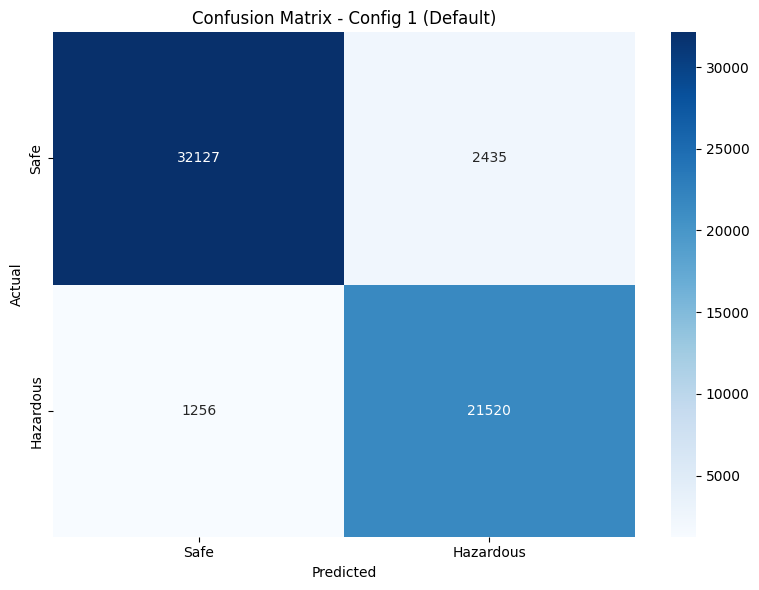


MODEL COMPARISON
   Metric  Baseline (LR)  ANN (Best)
 Accuracy       0.923995    0.935627
Precision       0.919812    0.898351
   Recall       0.885889    0.944854
 F1-Score       0.902532    0.921016


In [ ]:
print("="*50)
print("STEP 9: Final Model Evaluation on Test Set")
print("="*50)

# Get predictions
y_pred_proba = best_model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel: {best_config_name}")
print(f"\nTest Set Performance:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Hazardous']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Hazardous'],
            yticklabels=['Safe', 'Hazardous'])
plt.title(f'Confusion Matrix - {best_config_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Comparison with baseline
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline (LR)': [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline)
    ],
    'ANN (Best)': [accuracy, precision, recall, f1]
})
print(comparison_df.to_string(index=False))

## 11. VISUALIZATION OF TRAINING HISTORY

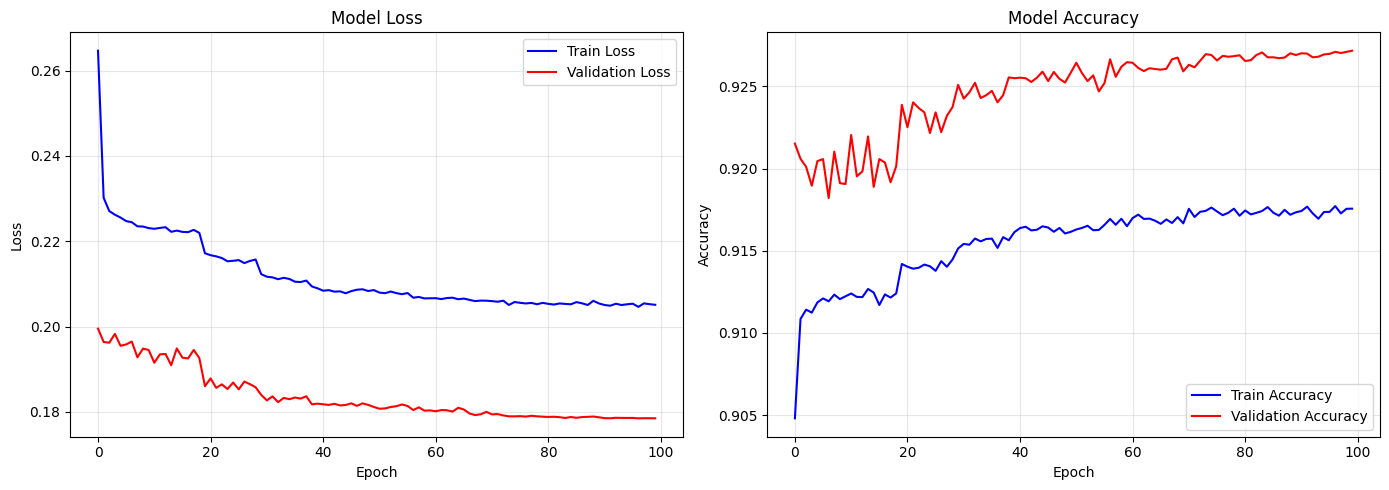

In [ ]:
# Find best model's training history
best_history = None
for r in results:
    if r['config'] == best_config_name:
        best_history = r['history']
        break

if best_history:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(best_history.history['loss'], label='Train Loss', color='blue')
    axes[0].plot(best_history.history['val_loss'], label='Validation Loss', color='red')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(best_history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[1].plot(best_history.history['val_accuracy'], label='Validation Accuracy', color='red')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 12. PROJECT SUMMARY

In [ ]:
print("="*60)
print("PROJECT SUMMARY FOR REPORT")
print("="*60)

print(f"""
Dataset Information:
- Total instances: {len(df_clean):,}
- Number of monitoring stations: {df_clean['station'].nunique() if 'station' in df_clean.columns else 'N/A'}
- Features used: {len(available_features)}
- Features: {available_features}
- Time period: March 2013 - February 2017
- Class distribution:
  - Safe (PM2.5 ≤ {PM25_THRESHOLD}): {(y==0).sum():,} samples ({(y==0).mean()*100:.1f}%)
  - Hazardous (PM2.5 > {PM25_THRESHOLD}): {(y==1).sum():,} samples ({(y==1).mean()*100:.1f}%)

Model Performance Summary:
- Best ANN Configuration: {best_config_name}
- Test Accuracy: {accuracy:.4f}
- Test Precision: {precision:.4f}
- Test Recall: {recall:.4f}
- Test F1-Score: {f1:.4f}

Comparison with Baseline:
- ANN Improvement over Logistic Regression:
  - Accuracy: +{(accuracy - accuracy_score(y_test, y_pred_baseline))*100:.1f}%
  - Recall: +{(recall - recall_score(y_test, y_pred_baseline))*100:.1f}%
""")

PROJECT SUMMARY FOR REPORT

Dataset Information:
- Total instances: 382,251
- Number of monitoring stations: 12
- Features used: 10
- Features: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
- Time period: March 2013 - February 2017
- Class distribution:
  - Safe (PM2.5 ≤ 75): 233,585 samples (61.1%)
  - Hazardous (PM2.5 > 75): 148,666 samples (38.9%)

Model Performance Summary:
- Best ANN Configuration: Config 1 (Default)
- Test Accuracy: 0.9356
- Test Precision: 0.8984
- Test Recall: 0.9449
- Test F1-Score: 0.9210

Comparison with Baseline:
- ANN Improvement over Logistic Regression:
  - Accuracy: +1.2%
  - Recall: +5.9%

